### Initialize the Environment:
##### Virtual Environment Commands

| Command | Linux/Mac | GitBash |
| ------- | --------- | ------- |
| Create | `python3 -m venv venv` | `python -m venv venv` |
| Activate | `source venv/bin/activate` | `source venv/Scripts/activate` |
| Install | `pip install -r requirements.txt` | `pip install -r requirements.txt` |
| Deactivate | `deactivate` | `deactivate` |
##### Select the Kernel (This will be in the Requirements.txt eventually)

Using the venv (Python 3.13.2) located  in venv/bin/python)

### **Analysis of the Data**
Capstone Project for Code:You Data Analysis track. This project analyzes Beer Recipes for frequency of uploads for various beer styles, while capturing preferences of strength, hopiness and batch size.    The goal of the project is to demonstrate a general knowledge of Python (Pandas, Numpy, MatLibPlot, Plotly), SQL(MySQL), Tableu, Cursor and ChatGPT.


In [1]:
# pip install openpyxl
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import openpyxl
# import numpy as np
import matplotlib as plt
from pandas import DataFrame

In [3]:
beer_recipes = pd.read_pickle("cleaned_beer_recipes.pkl")
bjcp_style = pd.read_pickle("cleaned_styles_2021.pkl")

In [4]:
print(beer_recipes.info)
print(bjcp_style.info)

<bound method DataFrame.info of                                      Recipe Name                Style  \
0             Avg. Perfect Northeast IPA (NEIPA)             Hazy IPA   
1                   Sierra Nevada Pale Ale Clone    American Pale Ale   
2                              Vanilla Cream Ale            Cream Ale   
3                  Zombie Dust Clone - ALL GRAIN         American IPA   
4       Russian River Pliny The Elder (original)           Double IPA   
...                                          ...                  ...   
236774                                Mild (110)            Dark Mild   
236775                          Simcoe Mild (99)            Dark Mild   
236776         Malted Bliss, Wedding Barley Wine  English Barley Wine   
236777         Malted Bliss, Wedding Barley Wine  English Barley Wine   
236778                   More LPANE Goodness APA    American Pale Ale   

       Style Number     OG  Plato     FG    ABV     IBU Source  \
0               21C  1.06

In [5]:
# Used to create lookup table used to further clean up recipe data sources
#bjcp_style.to_excel('bjcp_style.xlsx', index=False)

In [6]:
# Checking combined data for adherence to the 116 Styles in the BJCP 2021 Style Guide

grouped_style = beer_recipes.groupby('Style Number')

grouped_styles = grouped_style.size()
grouped_styles

Style Number
10A    5967
10B    1064
10C     610
11A    2047
11B    2248
       ... 
8A     1024
8B      916
9A      902
9B       57
9C     1056
Length: 115, dtype: int64

### **Data Visualization**

Chart 1: What is the distribution of the Beer Recipe Styles(Styles) among
the 116 styles

In [7]:
style_counts = style_counts[:35]
import matplotlib.pyplot as plt

# Group by 'Style' and count the number of occurrences
style_counts = beer_recipes['Style'].value_counts()

# Sort the data in descending order
style_counts = style_counts.sort_values(ascending=True)

# Group the first 35 styles and the rest into "Other Style"
top_styles = style_counts[:35]
# other_styles = pd.Series([style_counts[35:].sum()], index=['Other Style'])
# style_counts = pd.concat([top_styles, other_styles])

# Plot the bar chart horizontally
fig, ax = plt.subplots(figsize=(20, 15))
bars = ax.barh(style_counts.index, style_counts.values, color='skyblue')

# Highlight the top 2 bars
bars[0].set_color('gold')
bars[1].set_color('silver')

plt.xlabel('Number of Recipes')
plt.ylabel('Beer Styles')
plt.title('Number of Recipes per Beer Style')
plt.show()

NameError: name 'style_counts' is not defined

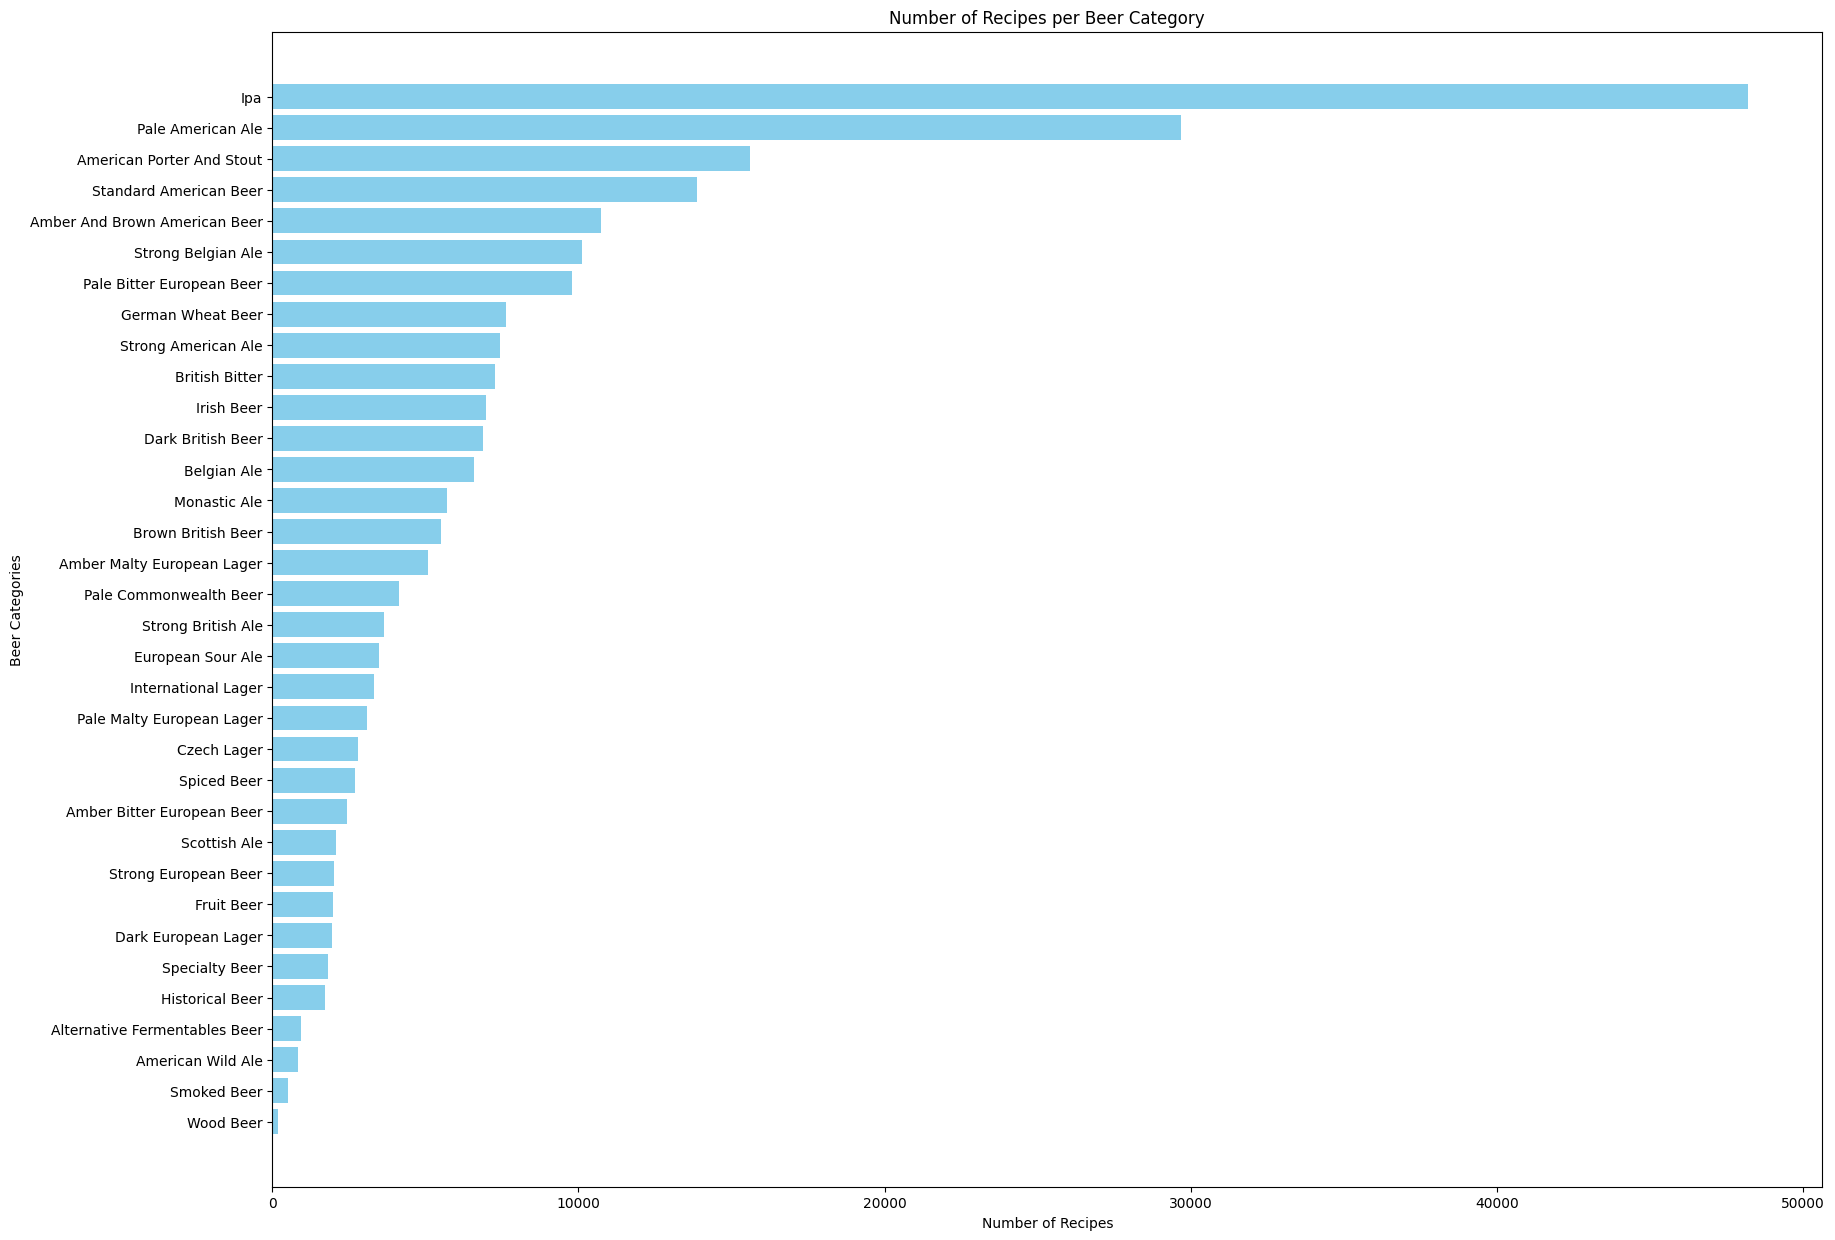

In [ ]:
# Group by 'Category' and count the number of occurrences
category_counts = beer_recipes['Category'].value_counts()

# Sort the data in descending order
category_counts = category_counts.sort_values(ascending=True)

# Plot the bar chart horizontally
fig, ax = plt.subplots(figsize=(20, 15))
bars = ax.barh(category_counts.index, category_counts.values, color='skyblue')

plt.xlabel('Number of Recipes')
plt.ylabel('Beer Categories')
plt.title('Number of Recipes per Beer Category')
plt.show()

import random

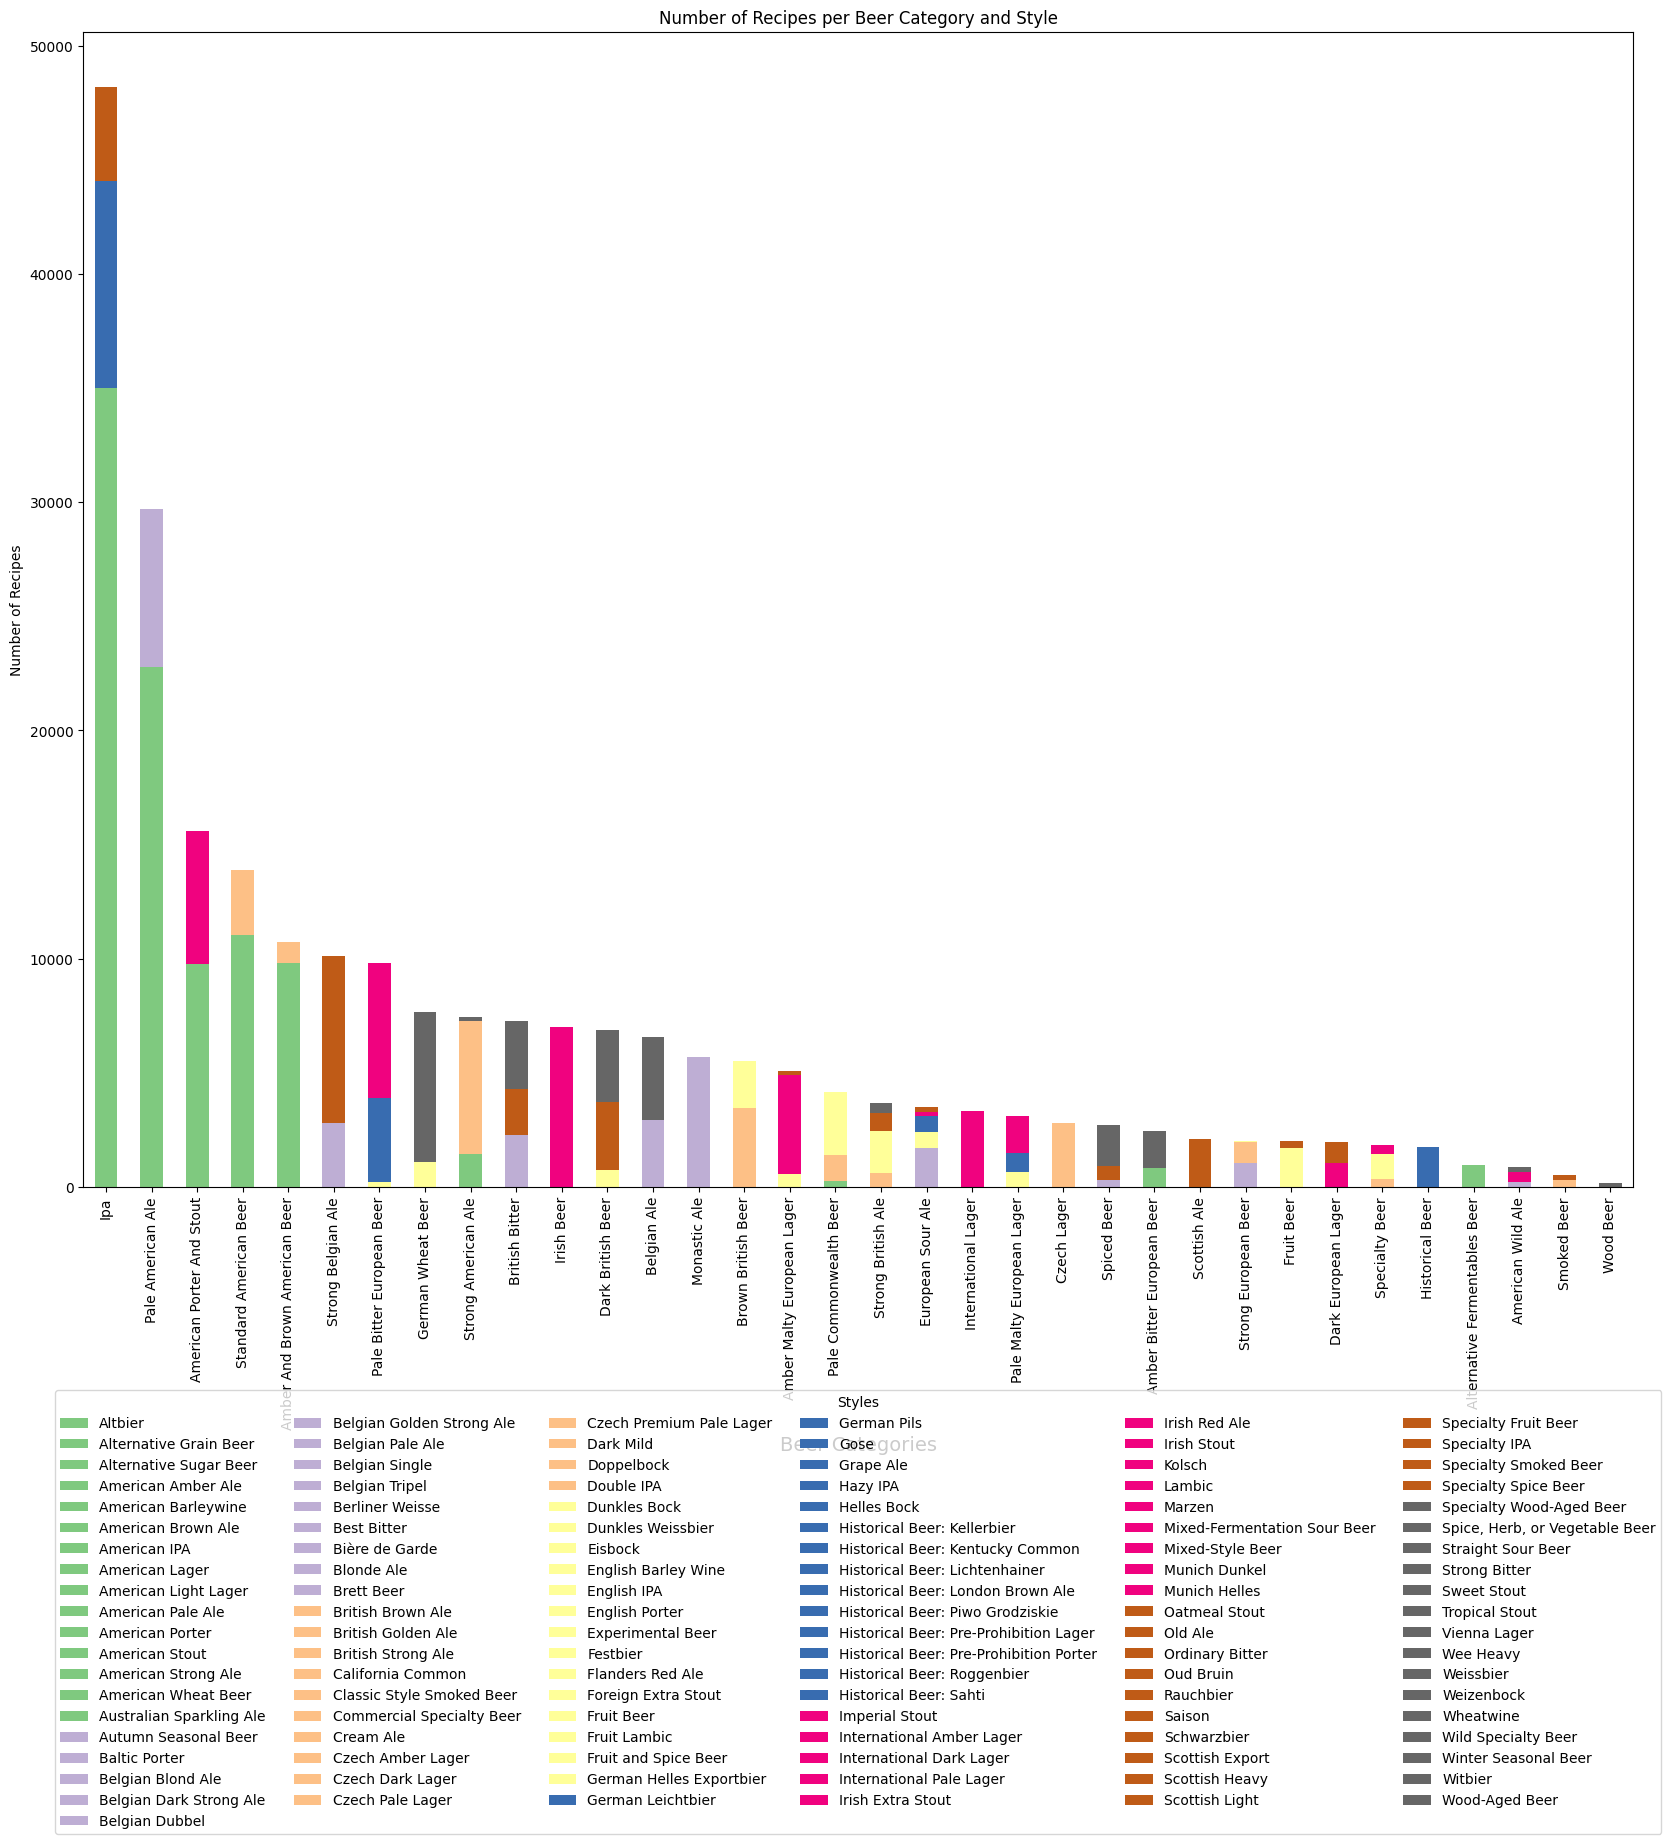

In [ ]:
# Group by 'Category' and 'Style' and count the number of occurrences
category_style_counts = beer_recipes.groupby(['Category', 'Style']).size().unstack().fillna(0)

# Sort the DataFrame by the sum of each category
category_style_counts = category_style_counts.loc[category_style_counts.sum(axis=1).sort_values(ascending=False).index]

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(20, 15))
category_style_counts.plot(kind='bar', stacked=True, ax=ax, colormap='Accent')

plt.xlabel('Beer Categories', fontsize=14)
plt.ylabel('Number of Recipes')
plt.title('Number of Recipes per Beer Category and Style')
plt.legend(title='Styles', bbox_to_anchor=(.5, -0.17), loc='upper center', ncol=6)
plt.show()

In [ ]:
print(plt.colormaps())  # Lists all available colormaps

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

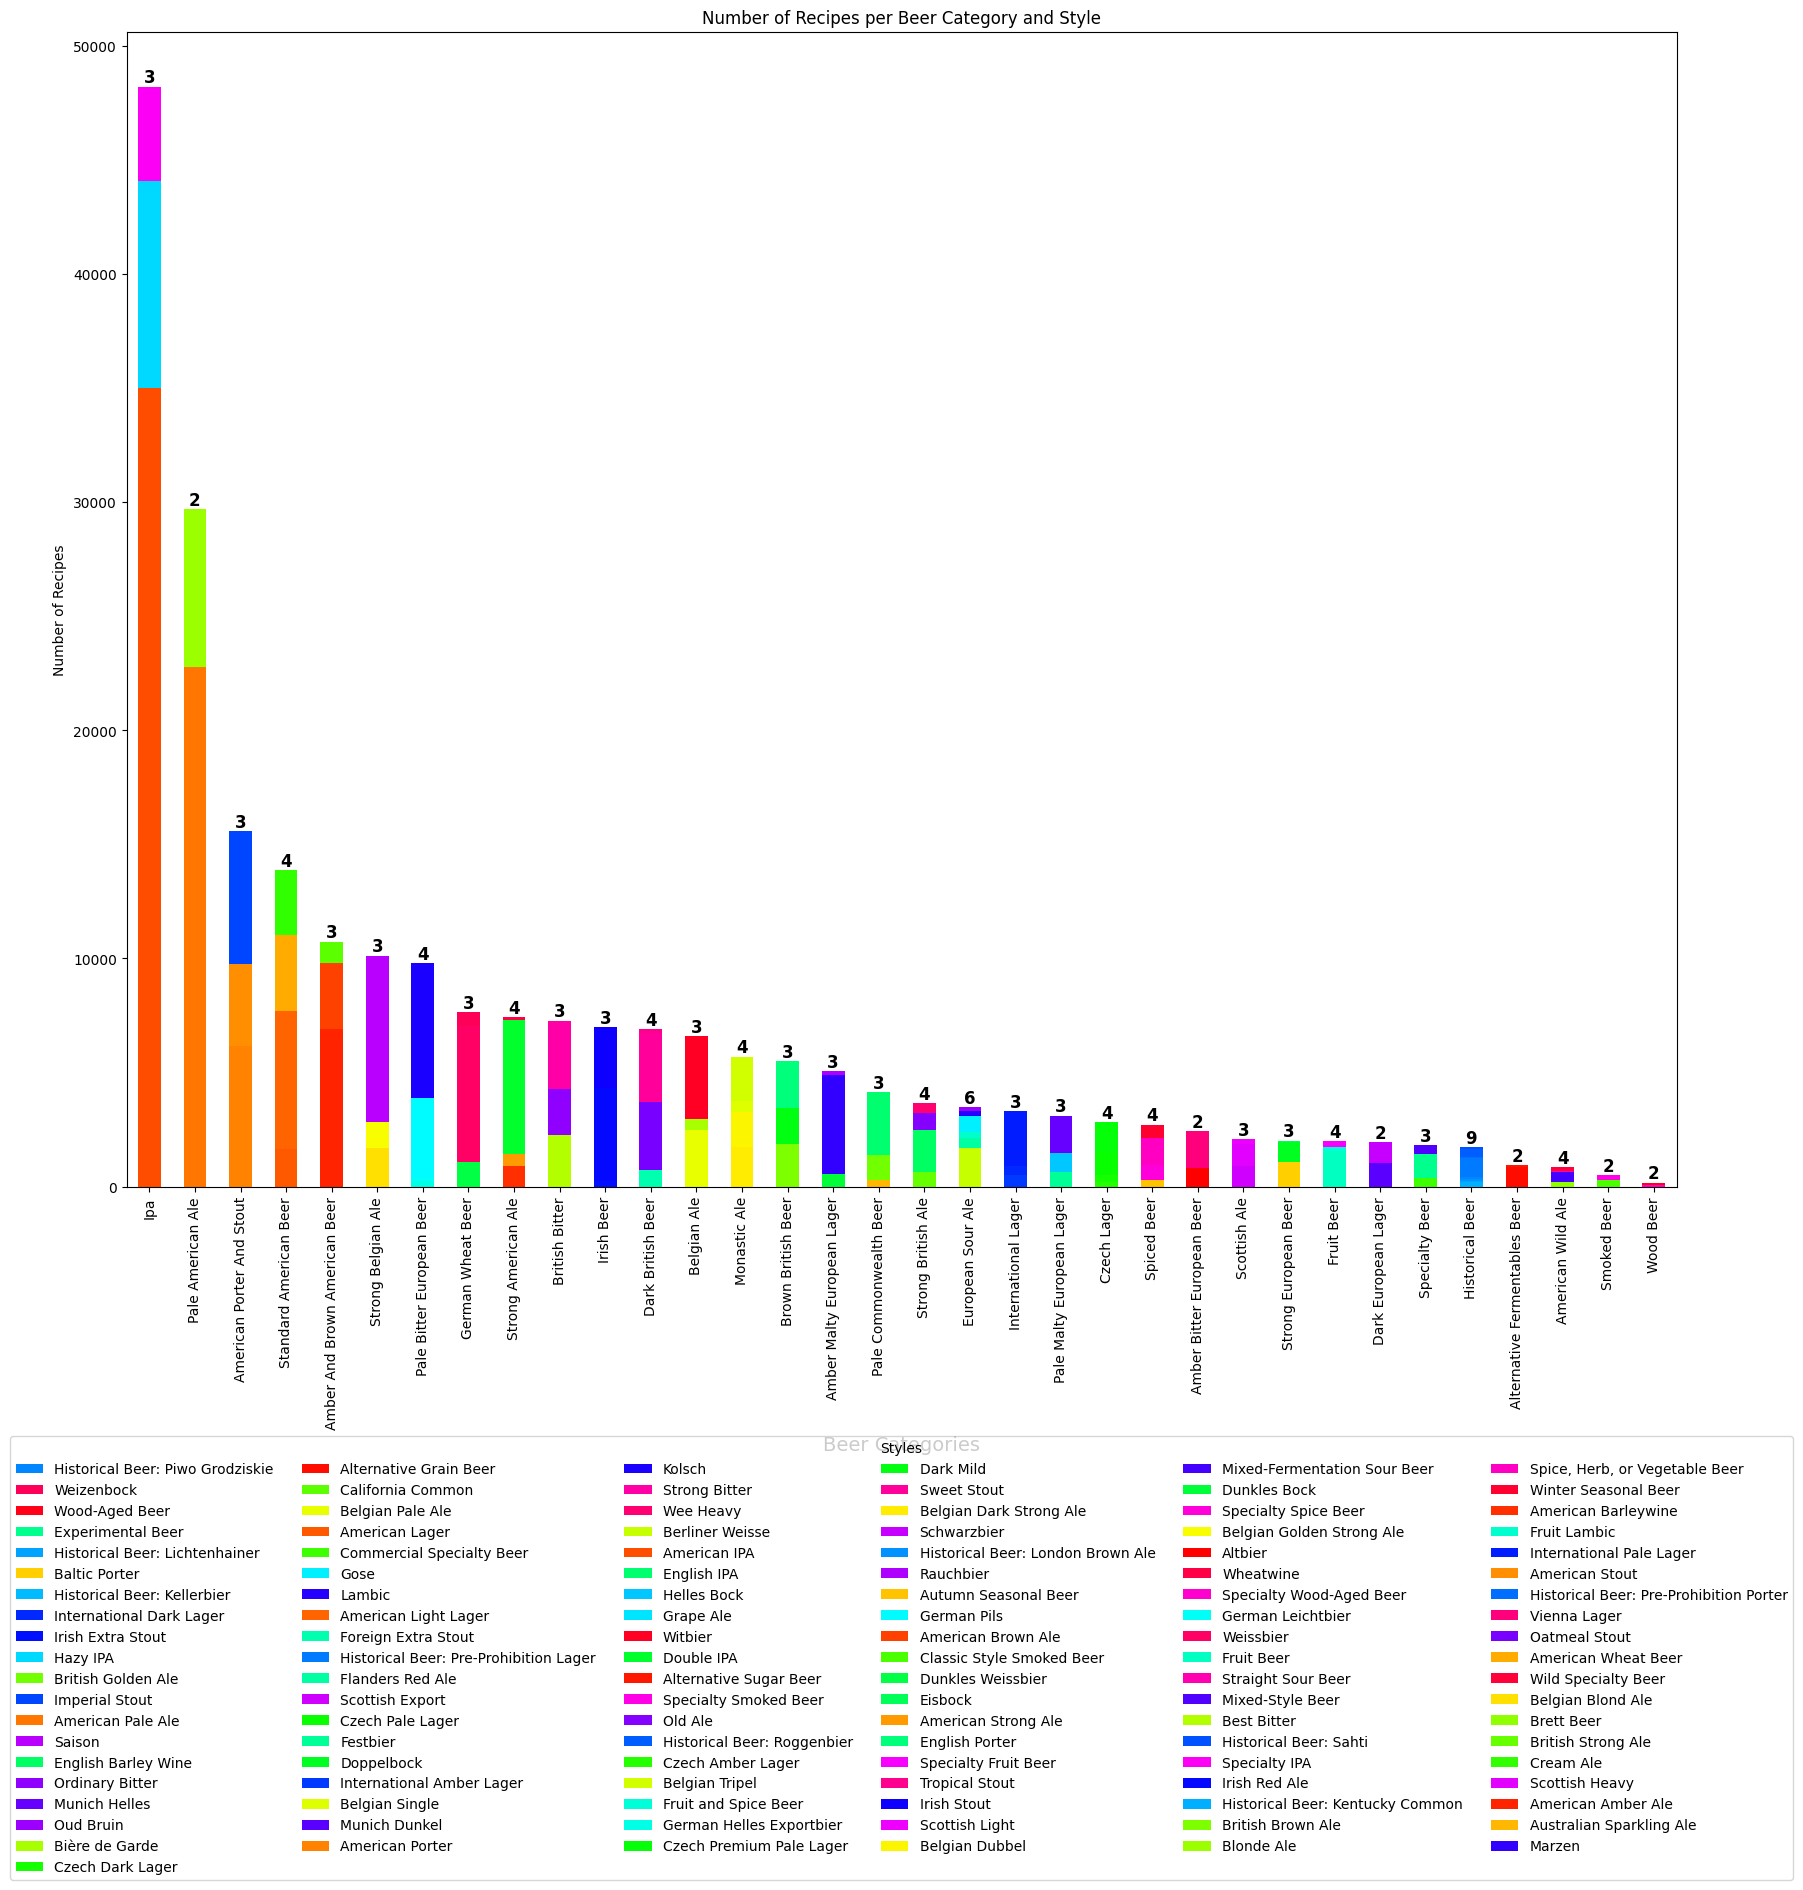

In [10]:
import matplotlib.pyplot as plt
#
import random

# Group by 'Category' and 'Style' and count the number of occurrences
category_style_counts = beer_recipes.groupby(['Category', 'Style']).size().unstack().fillna(0)

# Sort categories by total count (largest first)
category_style_counts = category_style_counts.loc[category_style_counts.sum(axis=1).sort_values(ascending=False).index]

# Shuffle the style order randomly for the legend
random.seed(42)
shuffled_styles = list(category_style_counts.columns)
random.shuffle(shuffled_styles)

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(20, 15))
category_style_counts.plot(kind='bar', stacked=True, ax=ax, colormap='hsv')

plt.xlabel('Beer Categories', fontsize=14)
plt.ylabel('Number of Recipes')
plt.title('Number of Recipes per Beer Category and Style')

# Count unique styles per category
unique_styles_per_category = beer_recipes.groupby('Category')['Style'].nunique()

# Add text annotations above bars
for i, category in enumerate(category_style_counts.index):
    ax.text(i, category_style_counts.loc[category].sum(), f"{int(unique_styles_per_category.loc[category])}", ha='center', va='bottom', fontsize=12, fontweight='bold')

# Update legend with shuffled order
handles, labels = ax.get_legend_handles_labels()
shuffled_handles_labels = sorted(zip(handles, labels), key=lambda x: shuffled_styles.index(x[1]))
handles, labels = zip(*shuffled_handles_labels)
ax.legend(handles, labels, title='Styles', bbox_to_anchor=(.5, -0.21), loc='upper center', ncol=6)

plt.show()


In [ ]:
import numpy as np
import random

import matplotlib.pyplot as plt

# Group by 'Category' and 'Style' and count the number of occurrences
category_style_counts = beer_recipes.groupby(['Category', 'Style']).size().unstack().fillna(0)

# Sort categories by total count (largest first)
category_style_counts = category_style_counts.loc[category_style_counts.sum(axis=1).sort_values(ascending=False).index]

# Shuffle the style order randomly for the legend
random.seed(42)
shuffled_styles = list(category_style_counts.columns)
random.shuffle(shuffled_styles)

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(20, 15))
category_style_counts.plot(kind='bar', stacked=True, ax=ax, colormap='hsv')

plt.xlabel('Beer Categories', fontsize=14)
plt.ylabel('Number of Recipes')
plt.title('Number of Recipes per Beer Category and Style')

# Count unique styles per category
unique_styles_per_category = beer_recipes.groupby('Category')['Style'].nunique()

# Add text annotations above bars
for i, total in enumerate(category_style_counts.sum(axis=1)):
    ax.text(i, total, f"{int(unique_styles_per_category.iloc[i])}", ha='center', va='bottom', fontsize=12, fontweight='bold')

# Update legend with shuffled order
handles, labels = ax.get_legend_handles_labels()
shuffled_handles_labels = sorted(zip(handles, labels), key=lambda x: shuffled_styles.index(x[1]))
handles, labels = zip(*shuffled_handles_labels)
ax.legend(handles, labels, title='Styles', bbox_to_anchor=(.5, -0.21), loc='upper center', ncol=6)

plt.show()

# Group Group by by 'Category' 'Category' and and 'Style' 'Style' and and count count the the number number of of occurrences occurrences
category_style_counts
category_style_counts = = beer_recipes.groupby(['Category', beer_recipes.groupby(['Category', 'Style']).size().unstack().fillna(0) 'Style']).size().unstack().fillna(0)

#

# Sort Sort categories categories by by total total count count (largest (largest first) first)
category_style_counts
category_style_counts = category_style_counts.loc[category_style_counts.sum(axis == category_style_counts.loc[category_style_counts.sum(axis1).sort_values(ascending==1).sort_values(ascendingFalse).index]=


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Sample data creation for demonstration
import pandas as pd

# Example DataFrame creation
data = {
    'Category': ['IPA', 'IPA', 'IPA', 'Stout', 'Stout', 'Lager', 'Lager', 'Lager', 'Lager', 'Pale Ale', 'Pale Ale'],
    'Style': ['Hazy IPA', 'Double IPA', 'Specialty IPA', 'Oatmeal Stout', 'Imperial Stout', 'American Lager', 'German Lager', 'Czech Pilsner', 'Light Lager', 'American Pale Ale', 'English Pale Ale']
}

beer_recipes = pd.DataFrame(data)

# Count unique styles per category
category_style_counts = beer_recipes.groupby('Category')['Style'].nunique()

# Sort categories by total count
category_style_counts = category_style_counts.sort_values(ascending=False)

# Plot the bar chart
fig, ax = plt.subplots(figsize=(20, 15))
bars = category_style_counts.plot(kind='bar', ax=ax, color=plt.cm.tab10.colors)

plt.xlabel('Beer Categories', fontsize=14)
plt.ylabel('Number of Styles')
plt.title('Number of Unique Styles per Beer Category')

# Add text annotations above bars
for i, total in enumerate(category_style_counts):
    ax.text(i, total + 0.5, f"{int(total)}", ha='center', fontsize=12, fontweight='bold')

plt.show()

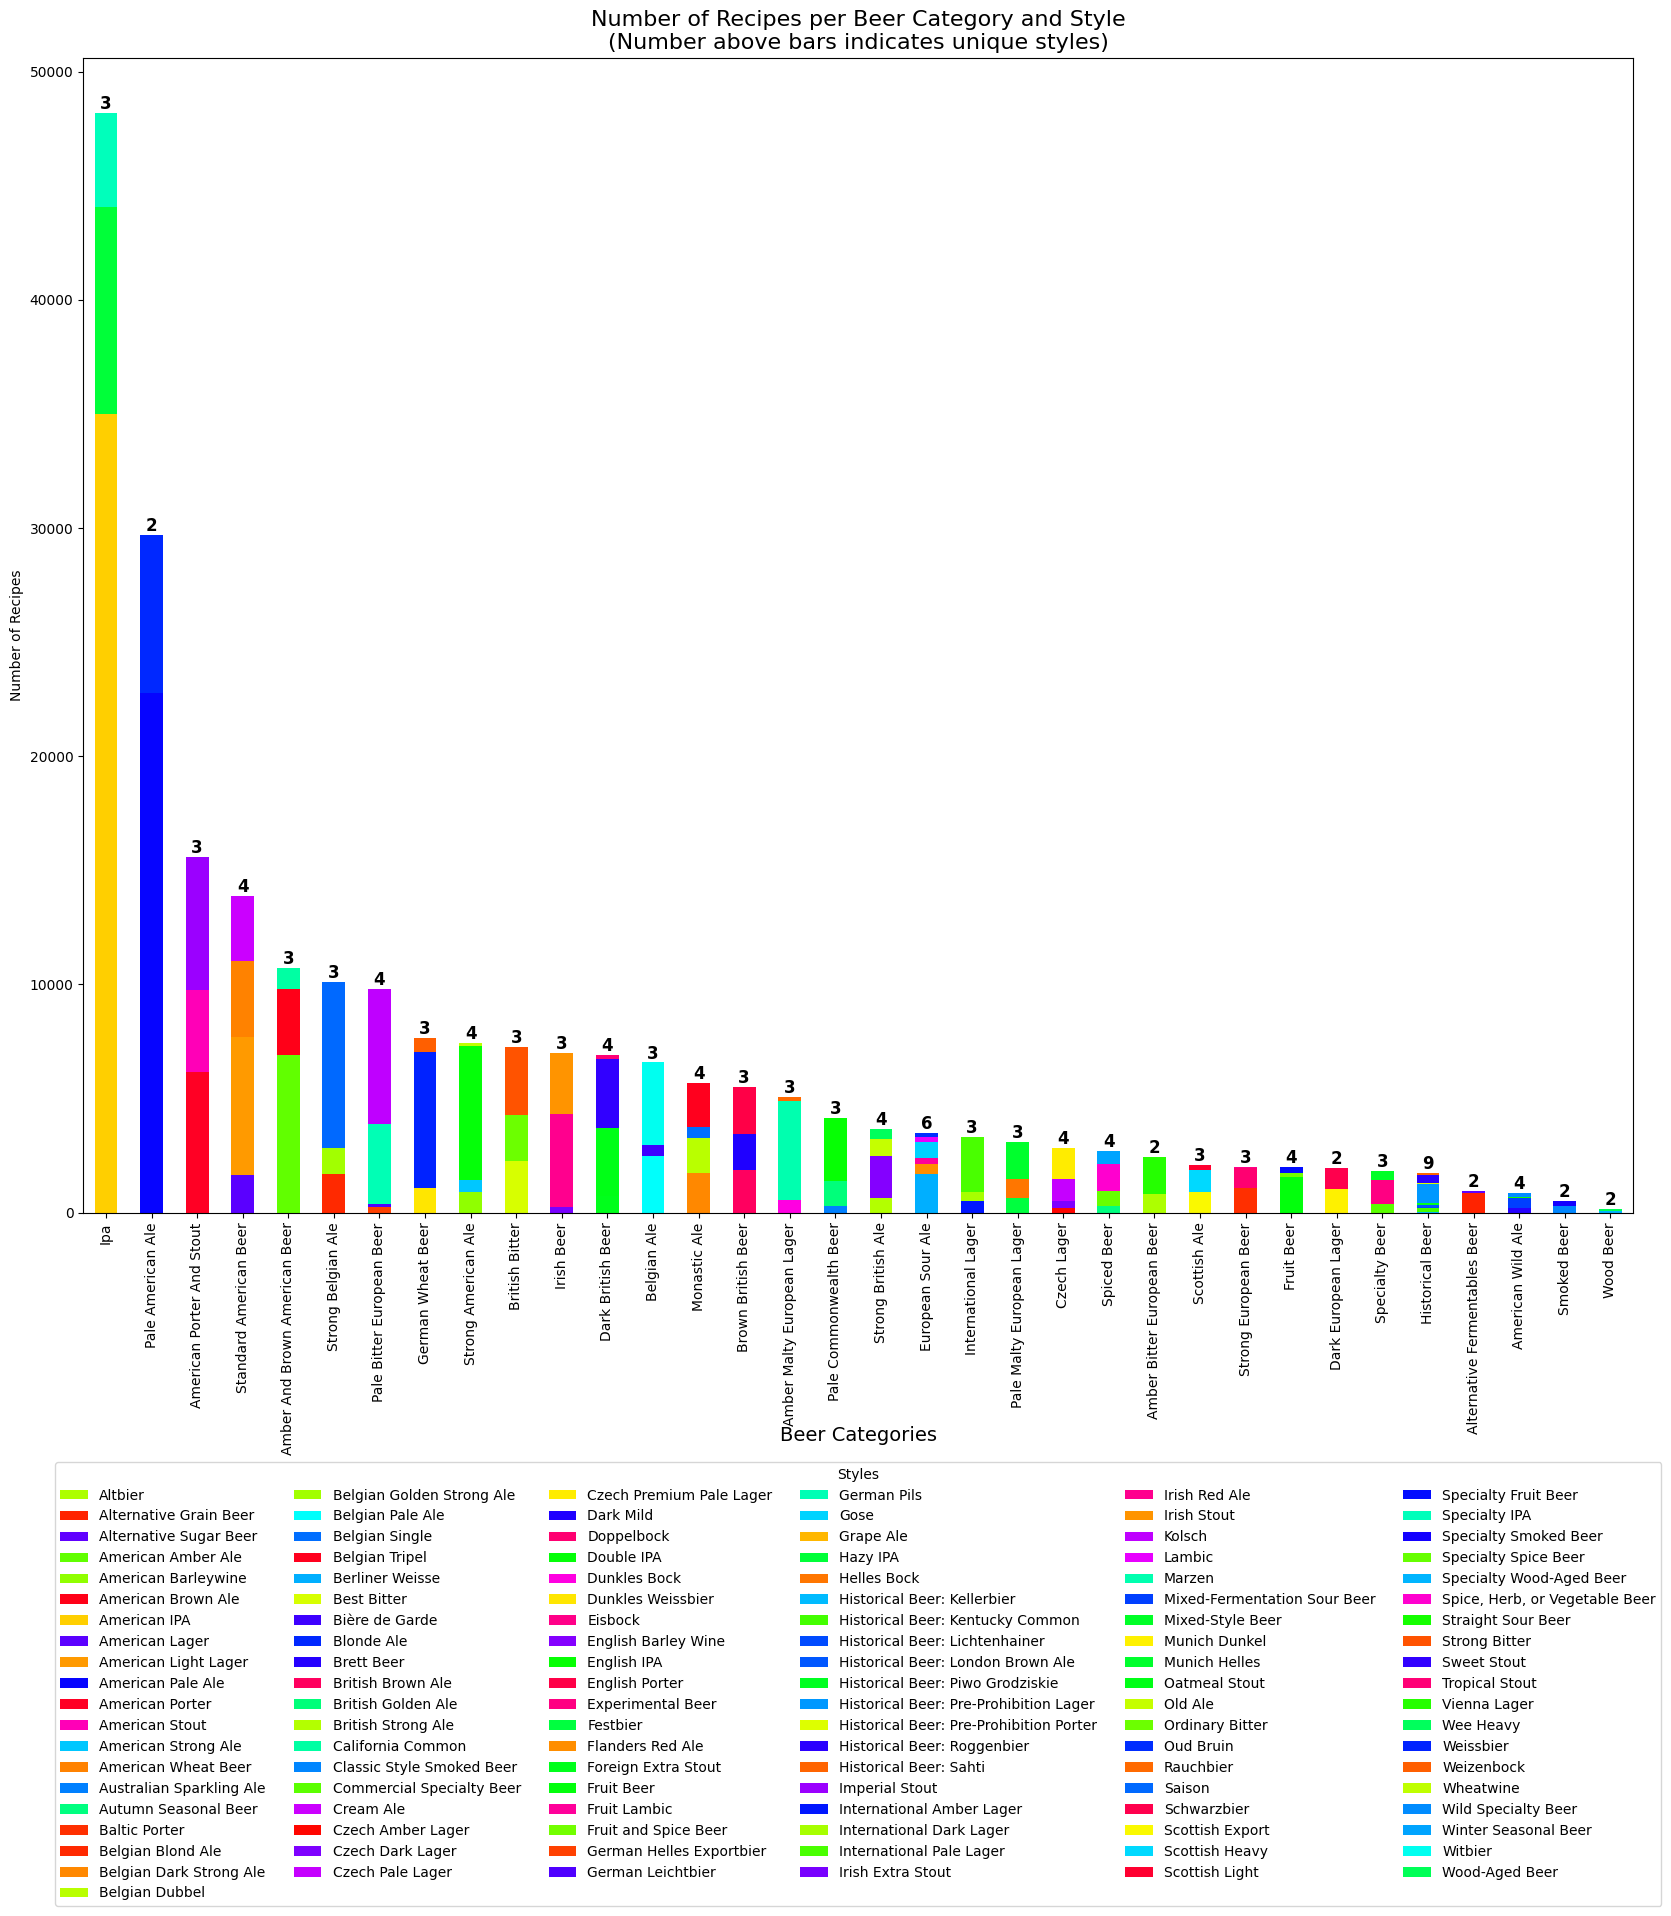

In [22]:
import matplotlib.pyplot as plt
import random
import matplotlib.colors as mcolors

# Group by 'Category' and 'Style' and count the number of occurrences
category_style_counts = beer_recipes.groupby(['Category', 'Style']).size().unstack().fillna(0)

# Sort categories by total count (largest first)
category_style_counts = category_style_counts.loc[category_style_counts.sum(axis=1).sort_values(ascending=False).index]

# Generate a list of random colors
random.seed(42)
n_colors = len(category_style_counts.columns)
colors = [mcolors.rgb2hex(plt.cm.hsv(i)) for i in random.sample(range(256), n_colors)]

# Create a custom colormap
custom_cmap = mcolors.ListedColormap(colors)

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(20, 15))
category_style_counts.plot(kind='bar', stacked=True, ax=ax, colormap=custom_cmap)

plt.xlabel('Beer Categories', fontsize=14)
ax.xaxis.set_label_coords(0.5, -0.185)  # Adjust the y-coordinate (second value) 
plt.ylabel('Number of Recipes')
plt.title('Number of Recipes per Beer Category and Style')

# Count unique styles per category
unique_styles_per_category = beer_recipes.groupby('Category')['Style'].nunique()

# Add text annotations above bars
for i, category in enumerate(category_style_counts.index):
    ax.text(i, category_style_counts.loc[category].sum(), f"{int(unique_styles_per_category.loc[category])}", ha='center', va='bottom', fontsize=12, fontweight='bold')

# Update legend with alphabetical order
# Worked with Perplexity to randomize the colors. When not randomized you could not
# discern the different volume of recipes by style visually.
handles, labels = ax.get_legend_handles_labels()
sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: x[1])
handles, labels = zip(*sorted_handles_labels)
ax.legend(handles, labels, title='Styles', bbox_to_anchor=(.5, -0.21), loc='upper center', ncol=6)
plt.title('Number of Recipes per Beer Category and Style\n(Number above bars indicates unique styles)', fontsize=16)
plt.show()
